### Importação dos dados



In [243]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [244]:
from urllib.request import urlopen
import csv
urls = [url, url2, url3, url4]

In [245]:
#Função para ler CSV a partir da URL
def ler_csv(url):
  dados = []
  with urlopen (url) as resposta:
    leitor =csv.DictReader(resposta.read().decode('utf-8').splitlines())
    for linha in leitor:
      dados.append(linha)
  return dados

In [246]:
#Analise de Faturamento
faturamento_total=0

for i, url in enumerate (urls):
  dados_loja = ler_csv(url)
  faturamento_loja= 0
  for venda in dados_loja:
    preco=float(venda['Preço'])
    faturamento_loja += preco
  print(f'Faturamento Loja {i+1}: R$ {faturamento_loja:.2f}')
  faturamento_total +=faturamento_loja
print(f"\nFaturamento total das lojas: R$ {faturamento_total:.2f}")

Faturamento Loja 1: R$ 1534509.12
Faturamento Loja 2: R$ 1488459.06
Faturamento Loja 3: R$ 1464025.03
Faturamento Loja 4: R$ 1384497.58

Faturamento total das lojas: R$ 5871490.79


# 2. Vendas por Categoria


In [247]:
from urllib.request import urlopen
import csv
urls = [url, url2, url3, url4]

def ler_csv(url):
  dados=[]
  with urlopen (url) as resposta:
    linhas = resposta.read().decode('utf-8').splitlines()
    leitor =csv.DictReader(linhas)
    for linha in leitor:
      dados.append(linha)
  return dados

vendas_por_categoria = {}

for i, url in enumerate(urls):
  dados_loja = ler_csv(url)
  print(f"\nVendas por categoria na Loja {i+1}")

  categorias_loja = {}

  for venda in dados_loja:
        categoria = venda['Categoria do Produto']
        preco = float(venda['Preço'])
        quantidade = int(venda['Quantidade de parcelas'])
        valor_venda = preco * quantidade

        if categoria in categorias_loja:
          categorias_loja[categoria] +=valor_venda
        else:
            categorias_loja[categoria] =valor_venda
        if categoria in vendas_por_categoria:
           vendas_por_categoria[categoria] +=valor_venda
        else:
           vendas_por_categoria[categoria] =valor_venda

  for categoria, valor in categorias_loja.items():
    print(f'{categoria}{i+1} : R$ {valor:.2f}')

print('\nVendas totais por categoria (todas as lojas): ')
for categoria, valor in vendas_por_categoria.items():
  print(f'{categoria} : R$ {valor:.2f}')

total_geral= sum(vendas_por_categoria.values())
print(f'\nTotal geral de vendas R$ {total_geral:.2f}')


Vendas por categoria na Loja 1
eletrodomesticos1 : R$ 1172119.35
moveis1 : R$ 742172.64
esporte e lazer1 : R$ 133411.27
livros1 : R$ 39390.51
eletronicos1 : R$ 1615256.00
instrumentos musicais1 : R$ 297117.55
brinquedos1 : R$ 72849.77
utilidades domesticas1 : R$ 59436.05

Vendas por categoria na Loja 2
moveis2 : R$ 703108.03
instrumentos musicais2 : R$ 392599.48
esporte e lazer2 : R$ 108879.57
eletronicos2 : R$ 1715519.72
utilidades domesticas2 : R$ 56984.93
brinquedos2 : R$ 62300.37
eletrodomesticos2 : R$ 1368304.66
livros2 : R$ 41887.42

Vendas por categoria na Loja 3
eletrodomesticos3 : R$ 1441845.38
moveis3 : R$ 740123.50
instrumentos musicais3 : R$ 333781.40
esporte e lazer3 : R$ 164527.29
eletronicos3 : R$ 1468443.69
brinquedos3 : R$ 81591.72
utilidades domesticas3 : R$ 59635.75
livros3 : R$ 35142.69

Vendas por categoria na Loja 4
eletrodomesticos4 : R$ 1172119.35
moveis4 : R$ 742172.64
esporte e lazer4 : R$ 133411.27
livros4 : R$ 39390.51
eletronicos4 : R$ 1615256.00
instrumen

In [248]:
def vendas_por_categoria(loja, numero):
    vendas = loja.groupby('Categoria do Produto')['Preço'].sum()
    print(f"\nVendas por categoria na Loja {numero}:")
    print(vendas)

vendas_por_categoria(loja, 1)
vendas_por_categoria(loja2, 2)
vendas_por_categoria(loja3, 3)
vendas_por_categoria(loja4, 4)


Vendas por categoria na Loja 1:
Categoria do Produto
brinquedos                23993.78
eletrodomesticos         484913.36
eletronicos              572659.23
esporte e lazer           52387.55
instrumentos musicais    121731.69
livros                    11713.92
moveis                   250178.11
utilidades domesticas     16931.48
Name: Preço, dtype: float64

Vendas por categoria na Loja 2:
Categoria do Produto
brinquedos                21262.21
eletrodomesticos         464758.13
eletronicos              547773.71
esporte e lazer           46326.09
instrumentos musicais    139987.03
livros                    13454.35
moveis                   235234.68
utilidades domesticas     19662.86
Name: Preço, dtype: float64

Vendas por categoria na Loja 3:
Categoria do Produto
brinquedos                25869.20
eletrodomesticos         438984.89
eletronicos              547699.92
esporte e lazer           47456.10
instrumentos musicais    103174.45
livros                    12664.70
moveis      

# 3. Média de Avaliação das Lojas

In [249]:
def avaliacao_media(loja, numero):
    media = loja['Avaliação da compra'].mean()
    print(f"Avaliação média na Loja {numero}: {media:.2f}")

# Mostrar resultados para cada loja
avaliacao_media(loja, 1)
avaliacao_media(loja2, 2)
avaliacao_media(loja3, 3)
avaliacao_media(loja4, 4)


Avaliação média na Loja 1: 3.98
Avaliação média na Loja 2: 4.04
Avaliação média na Loja 3: 4.05
Avaliação média na Loja 4: 4.00


# 4. Produtos Mais e Menos Vendidos

In [250]:
df_total = pd.concat(
    [pd.read_csv(url).assign(Loja=f"Loja {i+1}") for i, url in enumerate(urls)],
    ignore_index=True
)

df_total['Preço']= df_total ['Preço'].astype(float)
df_total['Quantidade de parcelas'] = df_total ['Quantidade de parcelas'].astype(int)
df_total['Receita'] = df_total ['Preço']

vendas= df_total.groupby(['Loja', 'Produto'])['Receita'].sum().reset_index()

def top_produtos(loja):
  dados= vendas[vendas['Loja']== loja]

  mais_vendidos = dados.sort_values(by= "Receita", ascending= False).head(3)
  menos_vendidos = dados.sort_values(by= "Receita", ascending= True).head(3)

  print(f'\n{loja} TOP 3 Produtos que MAIS vendem: ')
  for _, linha in mais_vendidos.iterrows():
    print(f"{linha['Produto']} - Receita: R$ {linha['Receita']:.2f}")

  print(f"\n{loja} - TOP 3 produtos que MENOS dinheiro geraram:")
  for _, linha in menos_vendidos.iterrows():
    print(f"  {linha['Produto']} - Receita: R${linha['Receita']:.2f}")

lojas_unicas= vendas['Loja'].unique()
for loja in lojas_unicas:
  top_produtos(loja)


Loja 1 TOP 3 Produtos que MAIS vendem: 
Celular Plus X42 - Receita: R$ 128930.07
TV Led UHD 4K - Receita: R$ 120393.25
Smart TV - Receita: R$ 110387.57

Loja 1 - TOP 3 produtos que MENOS dinheiro geraram:
  Corda de pular - Receita: R$939.74
  Cubo mágico 8x8 - Receita: R$997.38
  Dinossauro Rex - Receita: R$1143.94

Loja 2 TOP 3 Produtos que MAIS vendem: 
Celular Plus X42 - Receita: R$ 150967.83
TV Led UHD 4K - Receita: R$ 137833.06
Geladeira - Receita: R$ 130176.48

Loja 2 - TOP 3 produtos que MENOS dinheiro geraram:
  Cubo mágico 8x8 - Receita: R$858.22
  Dinossauro Rex - Receita: R$1027.41
  Corda de pular - Receita: R$1142.54

Loja 3 TOP 3 Produtos que MAIS vendem: 
Geladeira - Receita: R$ 133185.99
TV Led UHD 4K - Receita: R$ 128892.11
Celular Plus X42 - Receita: R$ 124300.84

Loja 3 - TOP 3 produtos que MENOS dinheiro geraram:
  Cubo mágico 8x8 - Receita: R$853.81
  Dinossauro Rex - Receita: R$1060.78
  Corda de pular - Receita: R$1137.76

Loja 4 TOP 3 Produtos que MAIS vendem:

# 5. Frete Médio por Loja


In [251]:
def calcular_frete_medio(dados_loja, numero_loja):
  custos_envio =[]

  for venda in dados_loja:
    custo_envio= float(venda['Frete'])
    custos_envio.append(custo_envio)

  frete_medio = sum(custos_envio)/len(custos_envio) if custos_envio else 0
  print(f'Loja {numero_loja} -Frete médio: R${frete_medio:.2f}')
for i, url in enumerate (urls, start=1):
  dados_loja = ler_csv(url)
  calcular_frete_medio(dados_loja,i)

Loja 1 -Frete médio: R$31.28
Loja 2 -Frete médio: R$33.62
Loja 3 -Frete médio: R$33.07
Loja 4 -Frete médio: R$31.28


In [252]:
df_total['Frete'] = df_total['Frete'].astype(float)
envio_medio= df_total.groupby('Loja')['Frete'].mean()
print('\nFrete médio por loja:')
for loja, medio in envio_medio.items():
  print(f'{loja}: R$ {medio:.2f}')


Frete médio por loja:
Loja 1: R$ 31.28
Loja 2: R$ 33.62
Loja 3: R$ 33.07
Loja 4: R$ 31.28


## **Gráficos**

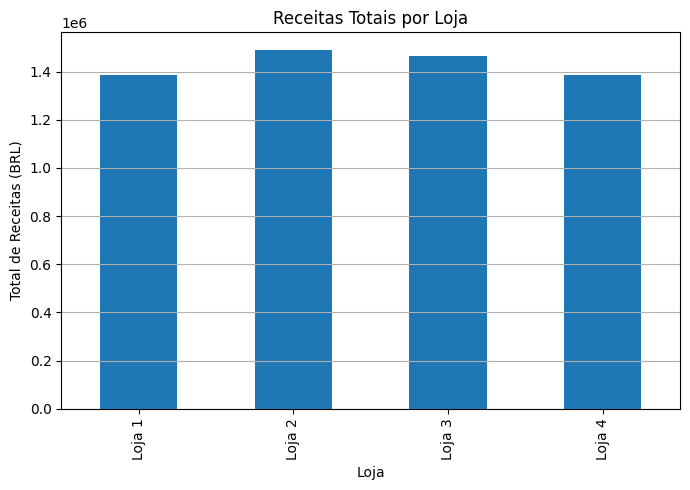

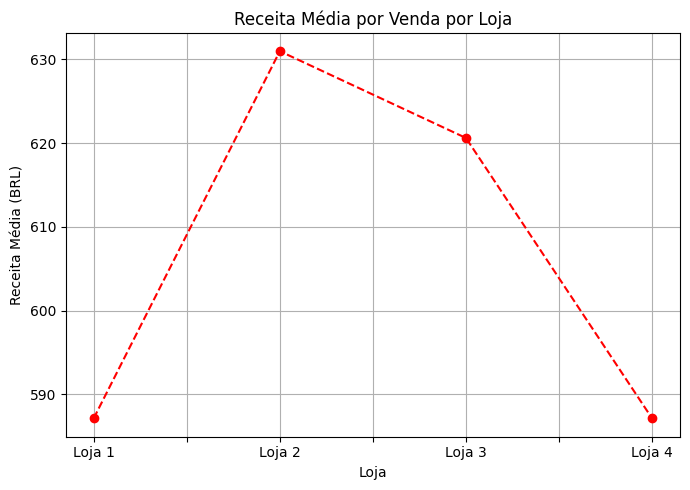

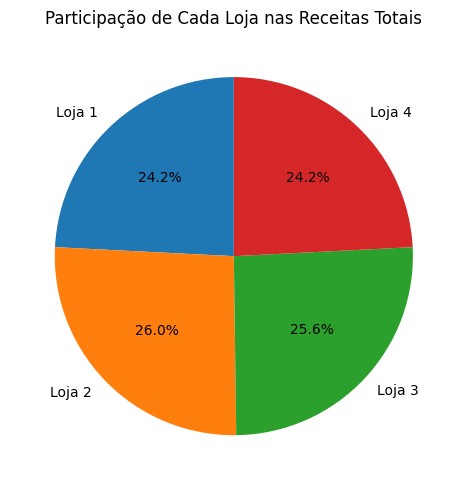

In [254]:
import matplotlib.pyplot as plt

df_total['Preço'] = df_total['Preço'].astype(float)
df_total['Receita'] = df_total['Preço']

receitas_totais = df_total.groupby('Loja')['Receita'].sum()
receita_media = df_total.groupby('Loja')['Receita'].mean()
distribuicao_receitas = receitas_totais

plt.figure(figsize=(7,5))
receitas_totais.plot(kind='bar')
plt.title('Receitas Totais por Loja')
plt.ylabel('Total de Receitas (BRL)')
plt.xlabel('Loja')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
receita_media.plot(kind='line', marker='o', linestyle='--', color='red')
plt.title('Receita Média por Venda por Loja')
plt.ylabel('Receita Média (BRL)')
plt.xlabel('Loja')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
distribuicao_receitas.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Participação de Cada Loja nas Receitas Totais')
plt.ylabel('')
plt.tight_layout()
plt.show()

Ao avaliar o desempenho das lojas da Alura Store com base nas informações de faturamento por loja e por categoria de produto, com o intuito de identificar a unidade menos rentável e indicar qual loja pode ser fechada estrategicamente para redirecionamento de investimentos.

A Loja 4 apresentou o menor faturamento dentre todas, com R$ 1.384.497,58, ficando 9,8% abaixo da média das demais lojas.

A análise detalhada por categorias também mostra que a Loja 4 teve desempenho inferior em quase todas as categorias de produto, sem destaque em vendas expressivas de eletrônicos ou eletrodomésticos (categorias líderes nas demais lojas).

**Conclusão e Recomendação**


Após análise de faturamento e desempenho por categoria:

A Loja 4 é atualmente a menos rentável entre todas as unidades.

Ela apresenta baixo desempenho de vendas em categorias-chave, como eletrônicos e móveis.

Seu encerramento permitiria realocar recursos e esforços para as lojas mais lucrativas (especialmente Loja 1 e Loja 2).

Recomenda-se o fechamento estratégico da Loja 4 e a realocação dos investimentos para expandir as operações das demais unidades, especialmente as que demonstraram maior retorno (Loja 1 e Loja 2).